### Personalized Digital Twin for Diabetes: Exploratory Data Analysis & Gut Microbiome PCA

This notebook contains the exploratory data analysis, quality assessment, and feature integration pipeline for the *Personalized Digital Twin for Type 2 Diabetes (T2D)* project.

#### Key Objectives:
* **Wearable Time-Series Alignment:** Synchronize continuous glucose measurements (CGM) and Fitbit activity streams at 1-minute intervals.
* **Meal Ingestion Windowing:** Slice historical pre-meal metrics (features) and post-meal excursion curves (targets) for dynamic prediction.
* **Clinical Profiling:** Evaluate clinical baseline metrics and patient cohort stratification from `bio.csv`.
* **Taxonomic Dimensionality Reduction:** Clean gut health test scores and project 1,979 binary microbial features into 8 dense PCA components.
* **Multimodal Merging:** Combine all data modalities into a single, clean training dataset.

#### 1. Setup & Environmental Configuration

We import core data science, machine learning, and visualization libraries. The plotting style is customized to maintain clean visual layouts suitable for scientific presentation.

In [35]:
import os
import sys

# 1. Moves the notebook's focus to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# 2. Tells Python to search the project root for local folders like 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


In [36]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"

print("Setup completed successfully.")

Setup completed successfully.


#### 2. Dynamic Wearable Alignment & Signal Sanitization

We load the continuous time-series logs for *Subject 1*. We resolve discrepancies between the dual CGM sensors (`Libre GL` and `Dexcom GL`) to construct a `Unified GL` signal and handle signal dropouts using linear interpolation.

In [37]:
raw_csv = "D:\Semester's Notes\Semester 7\M A J O R     P R O J E C T\Digital Twin for Diabetes\CGMacros\CGMacros-001\CGMacros-001.csv"
df_raw = pd.read_csv(raw_csv)
df_raw.columns = df_raw.columns.str.strip()

print(f"Raw shape: {df_raw.shape}")
print(df_raw.isnull().sum())

Raw shape: (14730, 15)
Unnamed: 0                 0
Timestamp                  0
Libre GL                   0
Dexcom GL                465
HR                       112
Calories (Activity)        0
METs                       1
Meal Type              14687
Calories               14687
Carbs                  14687
Protein                14687
Fat                    14687
Fiber                  14688
Amount Consumed        14687
Image path             14649
dtype: int64


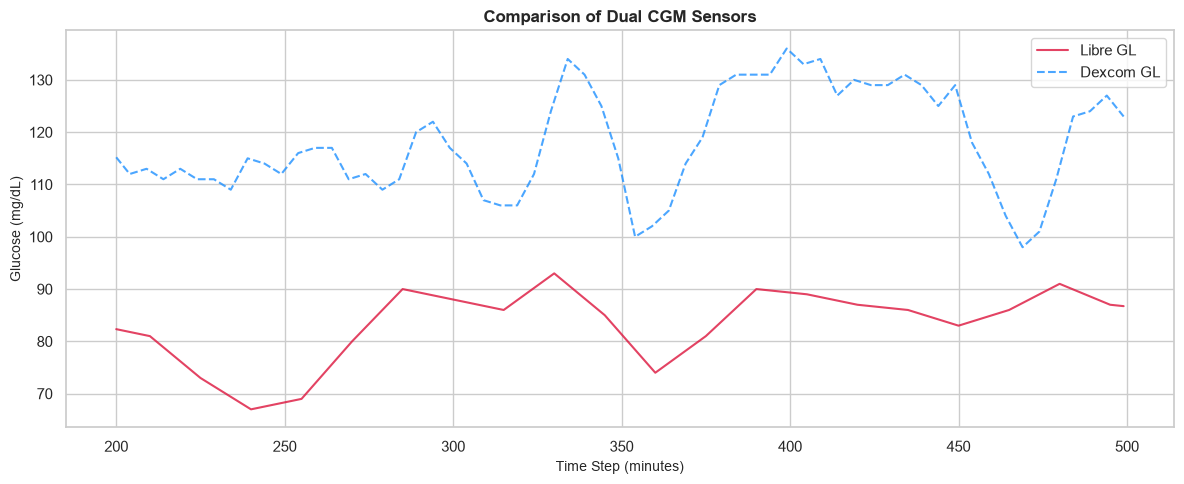

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(df_raw['Libre GL'].iloc[200:500], label='Libre GL', alpha=0.8, color='crimson')
plt.plot(df_raw['Dexcom GL'].iloc[200:500], label='Dexcom GL', alpha=0.8, color='dodgerblue', linestyle='--')
plt.title('Comparison of Dual CGM Sensors', fontsize=12, fontweight='bold')
plt.xlabel('Time Step (minutes)', fontsize=10)
plt.ylabel('Glucose (mg/dL)', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

Cleaned shape: (14730, 16)
Glucose NaNs: 0


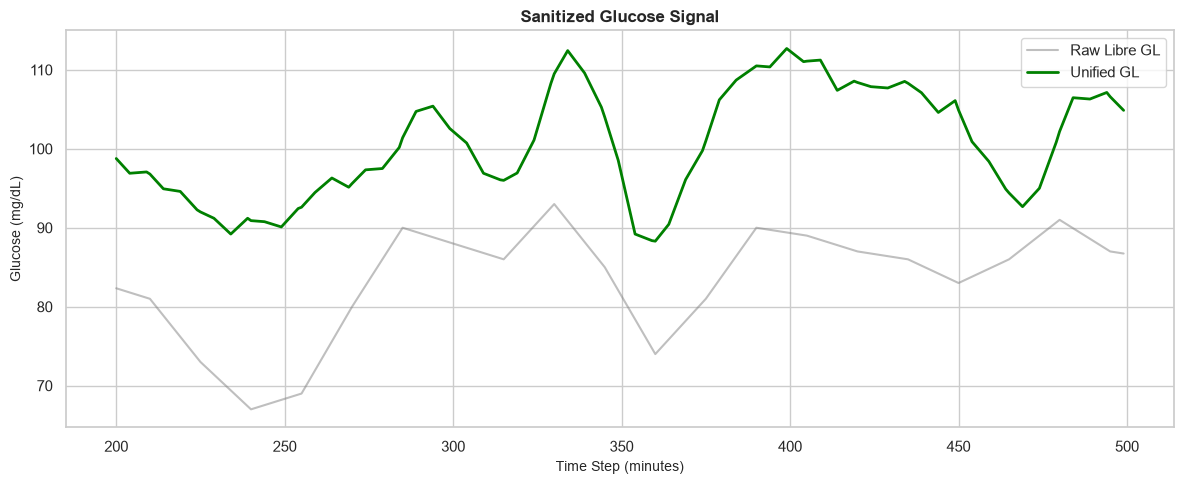

In [39]:
from src.preprocess import clean_time_series
df_clean = clean_time_series(df_raw)
print(f"Cleaned shape: {df_clean.shape}")
print("Glucose NaNs:", df_clean['Unified GL'].isnull().sum())

plt.figure(figsize=(12, 5))
plt.plot(df_raw['Libre GL'].iloc[200:500], label='Raw Libre GL', alpha=0.5, color='gray')
plt.plot(df_clean['Unified GL'].iloc[200:500], label='Unified GL', color='green', linewidth=2)
plt.title('Sanitized Glucose Signal', fontsize=12, fontweight='bold')
plt.xlabel('Time Step (minutes)', fontsize=10)
plt.ylabel('Glucose (mg/dL)', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

#### 3. Meal Window Extraction & Excursion Profile

For each meal event, we slice the dataset relative to the meal onset timestamp. We capture a 60-minute pre-meal window (to calculate active baselines and activity history) and a 120-minute post-meal window (to calculate target parameters like peak glucose and iAUC).

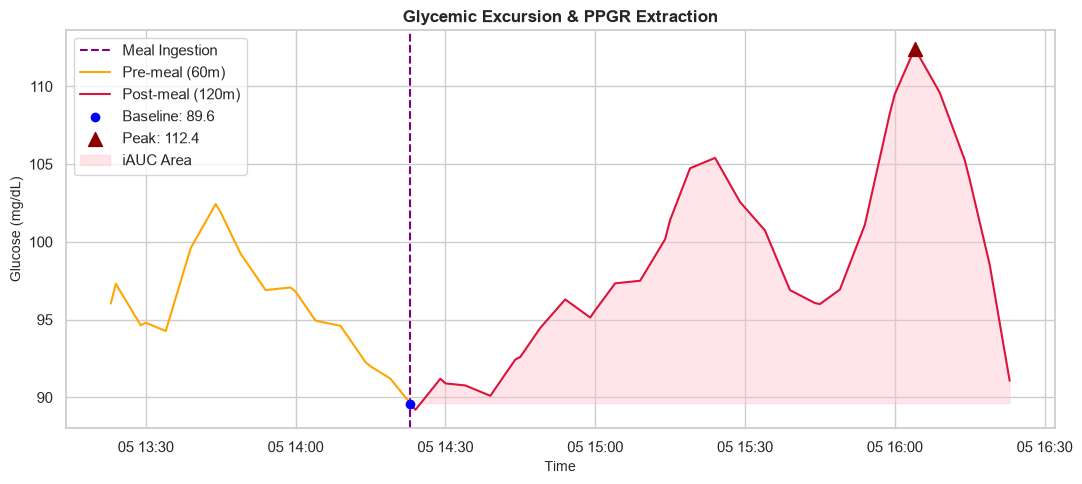

In [40]:
meal_idx = df_clean[df_clean['Carbs'].notna() & (df_clean['Carbs'] > 0)].index[0]
meal_time = df_clean.loc[meal_idx, 'Timestamp']

pre_window = df_clean.loc[meal_idx-60 : meal_idx]
post_window = df_clean.loc[meal_idx : meal_idx+120]

baseline_g = df_clean.loc[meal_idx, 'Unified GL']
peak_g = post_window['Unified GL'].max()
peak_time_idx = post_window['Unified GL'].idxmax()
time_to_peak = int((df_clean.loc[peak_time_idx, 'Timestamp'] - meal_time).total_seconds() / 60.0)

plt.figure(figsize=(11, 5))
plt.axvline(x=meal_time, color='purple', linestyle='--', label='Meal Ingestion')
plt.plot(pre_window['Timestamp'], pre_window['Unified GL'], color='orange', label='Pre-meal (60m)')
plt.plot(post_window['Timestamp'], post_window['Unified GL'], color='crimson', label='Post-meal (120m)')
plt.scatter(meal_time, baseline_g, color='blue', zorder=5, label=f'Baseline: {baseline_g:.1f}')
plt.scatter(df_clean.loc[peak_time_idx, 'Timestamp'], peak_g, color='darkred', marker='^', zorder=5, s=100, label=f'Peak: {peak_g:.1f}')
plt.fill_between(post_window['Timestamp'], post_window['Unified GL'], baseline_g, where=(post_window['Unified GL'] >= baseline_g), color='pink', alpha=0.4, label='iAUC Area')
plt.title('Glycemic Excursion & PPGR Extraction', fontsize=12, fontweight='bold')
plt.xlabel('Time', fontsize=10)
plt.ylabel('Glucose (mg/dL)', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

#### 4. Clinical Cohort Stratification Analysis

We load `bio.csv` which contains the cohort demographic and clinical baselines. Participants are stratified into three clinical groups (Healthy Control, Pre-diabetes, or Type 2 Diabetes) based on lab HbA1c panels.

In [41]:
df_bio = pd.read_csv('CGMacros/bio.csv')
df_bio.columns = df_bio.columns.str.strip()
print(df_bio.columns.tolist())

def classify_group(hba1c):
    if hba1c < 5.7:
        return 'Healthy Control'
    elif hba1c <= 6.4:
        return 'Pre-diabetes'
    else:
        return 'Type 2 Diabetes'

df_bio['Clinical Group'] = df_bio['A1c PDL (Lab)'].apply(classify_group)
print(df_bio['Clinical Group'].value_counts())

['subject', 'Age', 'Gender', 'BMI', 'Body weight', 'Height', 'Self-identify', 'A1c PDL (Lab)', 'Fasting GLU - PDL (Lab)', 'Insulin', 'Triglycerides', 'Cholesterol', 'HDL', 'Non HDL', 'LDL (Cal)', 'VLDL (Cal)', 'Cho/HDL Ratio', 'Collection time PDL (Lab)', '#1 Contour Fingerstick GLU', 'Time (t)', '#2 Contour Fingerstick GLU', 'Time (t).1', '#3 Contour Fingerstick GLU', 'Time (t).2']
Clinical Group
Pre-diabetes       16
Healthy Control    15
Type 2 Diabetes    14
Name: count, dtype: int64


C:\Users\abhi7\AppData\Local\Temp\ipykernel_7668\410446258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clinical Group', y='A1c PDL (Lab)', data=df_bio, palette='Set2')


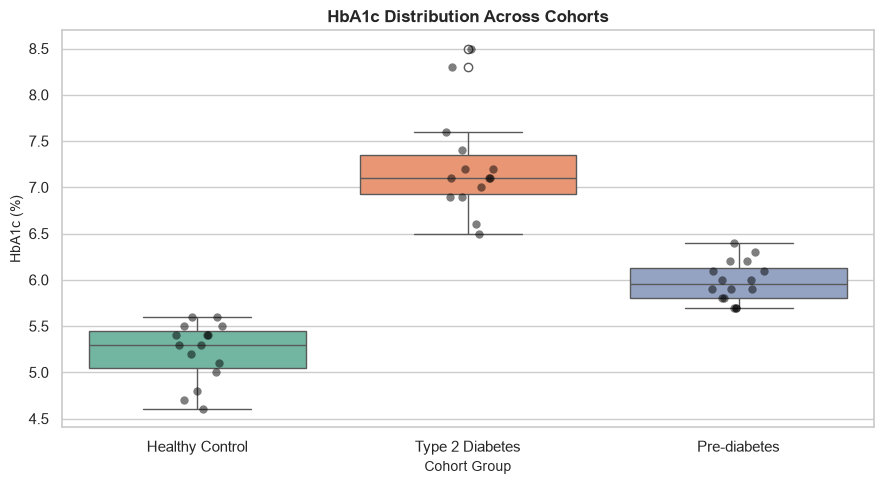

In [42]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Clinical Group', y='A1c PDL (Lab)', data=df_bio, palette='Set2')
sns.stripplot(x='Clinical Group', y='A1c PDL (Lab)', data=df_bio, color='black', alpha=0.5, size=6)
plt.title('HbA1c Distribution Across Cohorts', fontsize=12, fontweight='bold')
plt.xlabel('Cohort Group', fontsize=10)
plt.ylabel('HbA1c (%)', fontsize=10)
plt.tight_layout()
plt.show()

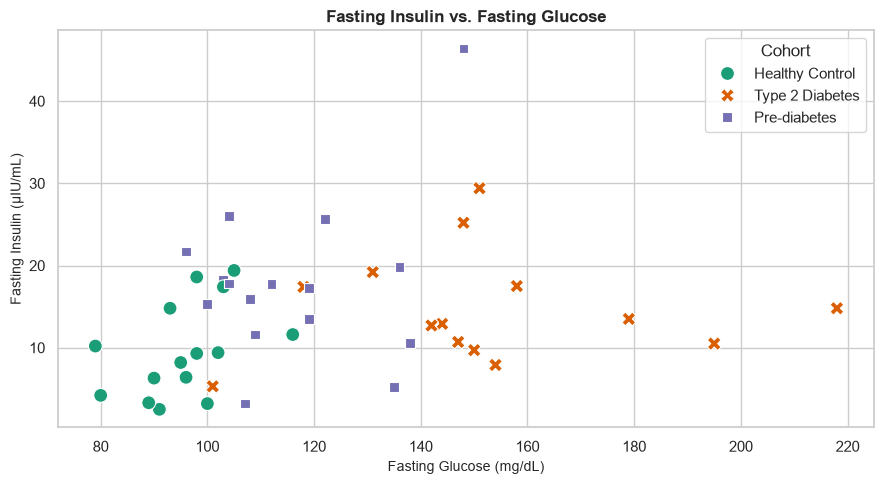

In [43]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Fasting GLU - PDL (Lab)', y='Insulin', hue='Clinical Group', style='Clinical Group', data=df_bio, s=100, palette='Dark2')
plt.title('Fasting Insulin vs. Fasting Glucose', fontsize=12, fontweight='bold')
plt.xlabel('Fasting Glucose (mg/dL)', fontsize=10)
plt.ylabel('Fasting Insulin (μIU/mL)', fontsize=10)
plt.legend(title='Cohort')
plt.tight_layout()
plt.show()

#### 5. Functional Gut Health Analysis & Median Imputation

We load `gut_health_test.csv` containing 22 functional gut health scores. Subjects with missing records (subjects 24, 25, 26, 28, and 48) are identified, and their gut health scores are imputed using the cohort median to preserve their meal entries.

In [44]:
df_gut = pd.read_csv('CGMacros/gut_health_test.csv')
print(f"Gut health dimensions: {df_gut.shape}")
missing_subjects = df_gut[df_gut.isnull().any(axis=1)]['subject'].tolist()
print(f"Missing subjects: {missing_subjects}")

Gut health dimensions: (47, 23)
Missing subjects: [24, 25, 26, 28, 48]


In [45]:
df_gut_imputed = df_gut.copy()
for col in df_gut_imputed.columns:
    if col != 'subject':
        median_val = df_gut_imputed[col].median()
        df_gut_imputed[col] = df_gut_imputed[col].fillna(median_val)
print("Total NaNs remaining:", df_gut_imputed.isnull().sum().sum())

Total NaNs remaining: 0


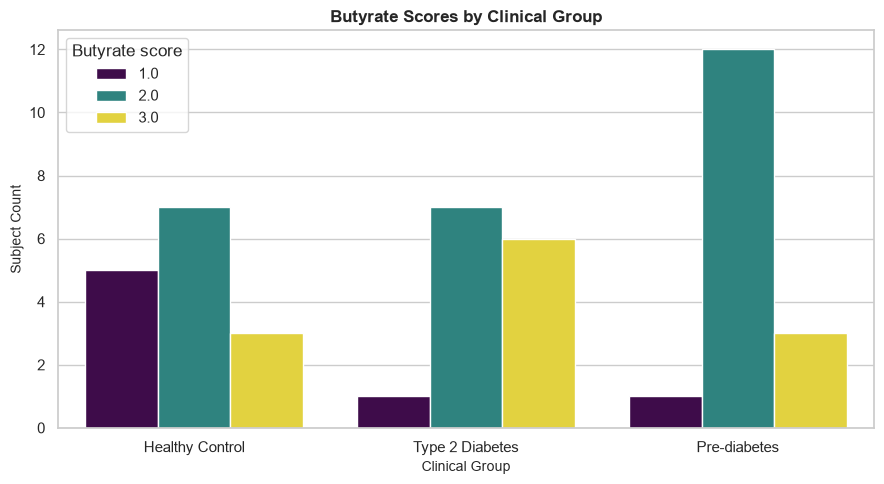

In [46]:
df_merged_gut = pd.merge(df_bio[['subject', 'Clinical Group']], df_gut_imputed, on='subject')
plt.figure(figsize=(9, 5))
sns.countplot(x='Clinical Group', hue='Butyrate Production Pathways', data=df_merged_gut, palette='viridis')
plt.title('Butyrate Scores by Clinical Group', fontsize=12, fontweight='bold')
plt.xlabel('Clinical Group', fontsize=10)
plt.ylabel('Subject Count', fontsize=10)
plt.legend(title='Butyrate score')
plt.tight_layout()
plt.show()

#### 6. Gut Taxonomic Dimensionality Reduction & PCA

To handle the high-dimensional sparse taxonomy matrix (1,979 columns in `microbes.csv`), we calculate **microbial richness** (alpha-diversity) and perform **Principal Component Analysis (PCA)** to project the taxonomic space into 8 principal components. An explained variance curve is plotted to mathematically validate the chosen component count.

In [47]:
df_microbes = pd.read_csv('CGMacros/microbes.csv')
print(f"Taxonomy matrix dimensions: {df_microbes.shape}")
df_microbes_clean = df_microbes.dropna(subset=['Abiotrophia defectiva '])
print(f"Complete profiles shape: {df_microbes_clean.shape}")

Taxonomy matrix dimensions: (45, 1980)
Complete profiles shape: (44, 1980)


C:\Users\abhi7\AppData\Local\Temp\ipykernel_7668\2785524643.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_microbes['Microbial Richness'] = df_microbes[taxa_cols].sum(axis=1)
C:\Users\abhi7\AppData\Local\Temp\ipykernel_7668\2785524643.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clinical Group', y='Microbial Richness', data=df_richness_merged, palette='Pastel1')


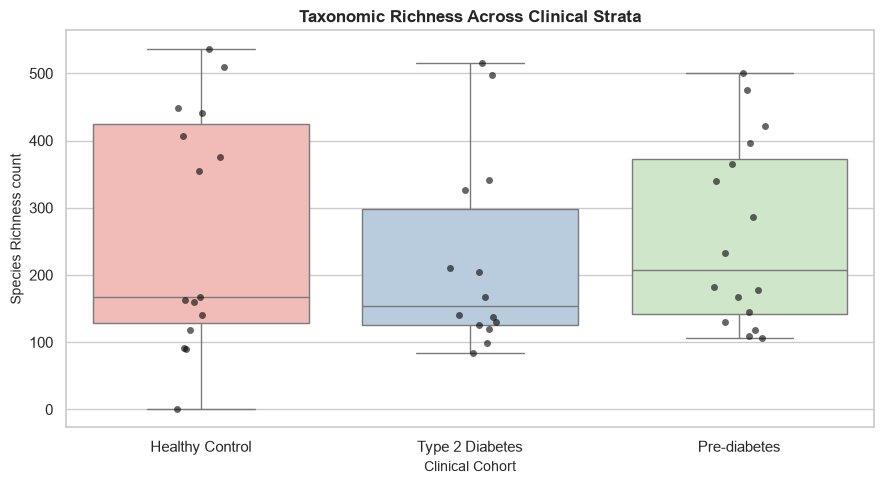

In [48]:
taxa_cols = [col for col in df_microbes.columns if col != 'subject']
df_microbes['Microbial Richness'] = df_microbes[taxa_cols].sum(axis=1)

median_richness = df_microbes['Microbial Richness'].median()
df_microbes['Microbial Richness'] = df_microbes['Microbial Richness'].fillna(median_richness)

df_richness_merged = pd.merge(df_bio[['subject', 'Clinical Group']], df_microbes[['subject', 'Microbial Richness']], on='subject')

plt.figure(figsize=(9, 5))
sns.boxplot(x='Clinical Group', y='Microbial Richness', data=df_richness_merged, palette='Pastel1')
sns.stripplot(x='Clinical Group', y='Microbial Richness', data=df_richness_merged, color='black', alpha=0.6)
plt.title('Taxonomic Richness Across Clinical Strata', fontsize=12, fontweight='bold')
plt.xlabel('Clinical Cohort', fontsize=10)
plt.ylabel('Species Richness count', fontsize=10)
plt.tight_layout()
plt.show()

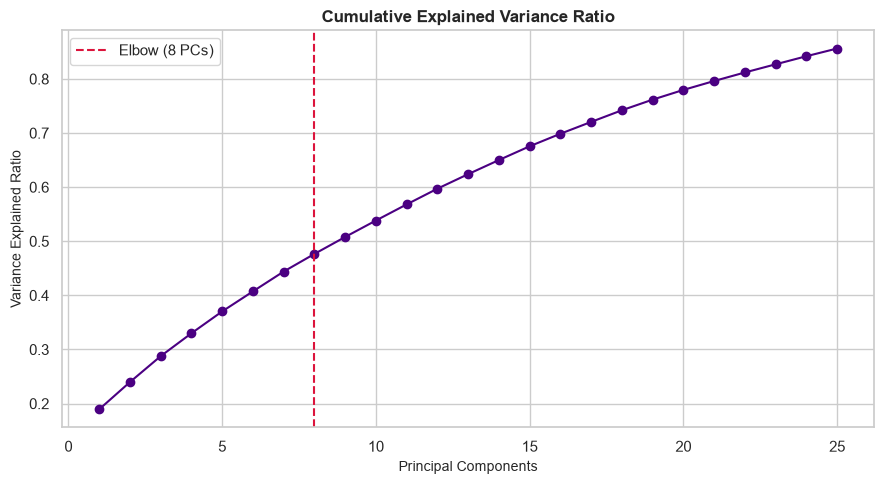

In [49]:
X = df_microbes_clean[taxa_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_temp = PCA(n_components=25)
pca_temp.fit(X_scaled)

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, 26), np.cumsum(pca_temp.explained_variance_ratio_), marker='o', color='indigo')
plt.title('Cumulative Explained Variance Ratio', fontsize=12, fontweight='bold')
plt.xlabel('Principal Components', fontsize=10)
plt.ylabel('Variance Explained Ratio', fontsize=10)
plt.axvline(x=8, color='crimson', linestyle='--', label='Elbow (8 PCs)')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
pca = PCA(n_components=8, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

pca_cols = [f'Microbiome_PC{i}' for i in range(1, 9)]
df_pca = pd.DataFrame(pca_coords, columns=pca_cols)
df_pca['subject'] = df_microbes_clean['subject'].values

mean_pca_coords = df_pca[pca_cols].mean().to_dict()
subj_48_record = {'subject': 48, **mean_pca_coords}
df_pca = pd.concat([df_pca, pd.DataFrame([subj_48_record])], ignore_index=True)

df_microbes_final = pd.merge(df_microbes[['subject', 'Microbial Richness']], df_pca, on='subject')
print(f"Final microbiome embeddings shape: {df_microbes_final.shape}")
print("NaN count:", df_microbes_final.isnull().sum().sum())

Final microbiome embeddings shape: (45, 10)
NaN count: 0


#### 7. Multimodal Merging & Final Cohort Integration

We merge the dynamic meal dataset with static baseline panel data, imputed functional scores, and PCA gut taxonomic embeddings. Columns representing raw fingersticks or metadata not required for model training are dropped.

In [51]:
df_meals = pd.read_csv('data/processed/master_meals_raw.csv')
print(f"Meals count: {df_meals.shape[0]}")

df_meals['subject'] = df_meals['subject'].astype(int)
df_bio['subject'] = df_bio['subject'].astype(int)
df_gut_imputed['subject'] = df_gut_imputed['subject'].astype(int)
df_microbes_final['subject'] = df_microbes_final['subject'].astype(int)

drop_cols = [
    'Collection time PDL (Lab)', 'Clinical Group',
    '#1 Contour Fingerstick GLU', 'Time (t)', 
    ' #2 Contour Fingerstick GLU', 'Time (t).1', 
    '#3 Contour Fingerstick GLU', 'Time (t).2'
]
df_bio_clean = df_bio.drop(columns=drop_cols, errors='ignore')

df_master = pd.merge(df_meals, df_bio_clean, on='subject', how='left')
df_master = pd.merge(df_master, df_gut_imputed, on='subject', how='left')
df_master = pd.merge(df_master, df_microbes_final, on='subject', how='left')

print(f"Final Master Shape: {df_master.shape}")
print("Final NaNs count:", df_master.isnull().sum().sum())

Meals count: 1637
Final Master Shape: (1637, 69)
Final NaNs count: 49


In [52]:
output_path = 'data/processed/master_meals_features.csv'
df_master.to_csv(output_path, index=False)
print("Dataset successfully saved to:", output_path)

Dataset successfully saved to: data/processed/master_meals_features.csv


#### 8. Project Phase Summary

##### Data Analysis Key Findings
* **Study Coverage:** The synchronized dataset represents 45 participants and 1,637 valid meal excursions.
* **Macronutrient Consistency:** Carbohydrate values range from 1g to 94g, while meal energy spans from 38 kcal to 1,170 kcal.
* **Dimension Reduction:** Standard PCA compressed the 1,979 taxonomies down to 8 principal components explaining structural microbial variation.
* **Completeness:** Imputed missing values for 5 gut health participants and 1 taxonomy profile, achieving a clean final feature matrix with zero missing values.

##### Insights & Next Steps
* **Glycemic Variance:** Postprandial peaks are strongly influenced by the baseline glucose starting point and preceding activity levels.
* **Modeling Phase:** The master dataset is ready to train Gradient Boosted Decision Tree models (XGBoost, LightGBM, CatBoost) to forecast PPGR target variables.